<a href="https://colab.research.google.com/github/sivakrishnaps/AI-ML-session/blob/main/MLP_MNIST_std_with_montage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multi-Layer Perceptron Classification Model for MNIST Dataset

The MNIST database (Modified National Institute of Standards and Technology database) is a large database of handwritten digits that is commonly used for training various image processing systems. The database is also widely used for training and testing in the field of machine learning. It was created by "re-mixing" the samples from NIST's original datasets. The creators felt that since NIST's training dataset was taken from American Census Bureau employees, while the testing dataset was taken from American high school students, it was not well-suited for machine learning experiments. Furthermore, the black and white images from NIST were normalized to fit into a 28x28 pixel bounding box and anti-aliased, which introduced grayscale levels.

The MNIST database contains 60,000 training images and 10,000 testing images. Half of the training set and half of the test set were taken from NIST's training dataset, while the other half of the training set and the other half of the test set were taken from NIST's testing dataset. There have been a number of scientific papers on attempts to achieve the lowest error rate; one paper, using a hierarchical system of convolutional neural networks, manages to get an error rate on the MNIST database of 0.23%. The original creators of the database keep a list of some of the methods tested on it. In their original paper, they use a support-vector machine to get an error rate of 0.8%. An extended dataset similar to MNIST called EMNIST has been published in 2017, which contains 240,000 training images, and 40,000 testing images of handwritten digits and characters. We can recognize the images using our eyes with our pre-knowledge.

Neural networks approach the problem in a different way. The idea is to take a large number of handwritten digits, known as training examples, and then develop a system which can learn from those training examples. In other words, the neural network uses the examples to automatically infer rules for recognizing handwritten digits. Furthermore, by increasing the number of training examples, the network can learn more about handwriting, and so improve its accuracy. So a NN could build a better handwriting recognizer by using thousands or even millions or billions of training examples.

## Stages in Model design & Development
1. Importing libraries & dataset
2. Data preprocessing
3. Network model design
4. Compile the model
5. Train the model
6. Performance evaluation & reporting

# **Importing Libraries**

In [ ]:
import numpy as np
import tensorflow
import matplotlib.pyplot as plt

# **Load Data**

In [ ]:
from tensorflow.keras.datasets import mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

# **Checkout the Data**

Training data shape:  (60000, 28, 28) (60000,)
Testing data shape:  (10000, 28, 28) (10000,)
Total number of outputs:  10
Output classes:  [0 1 2 3 4 5 6 7 8 9]


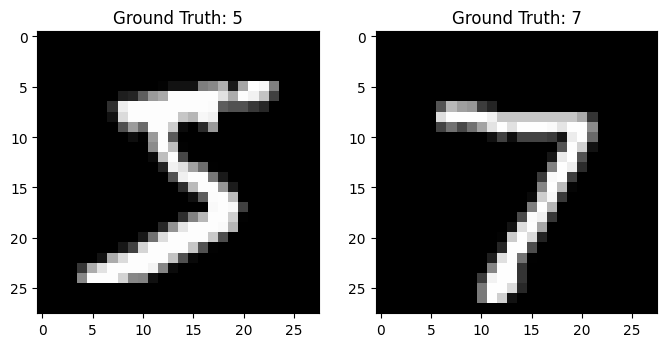

In [ ]:
print('Training data shape: ', train_images.shape, train_labels.shape)
print('Testing data shape: ', test_images.shape, test_labels.shape)
classes = np.unique(train_labels)
nClasses = len(classes)
print('Total number of outputs: ', nClasses)
print('Output classes: ', classes)
plt.figure(figsize=[8, 8])
plt.subplot(121)
plt.imshow(train_images[0], cmap='gray')
plt.title('Ground Truth: {}'.format(train_labels[0]))
plt.subplot(122)
plt.imshow(test_images[0], cmap='gray')
plt.title('Ground Truth: {}'.format(test_labels[0]))
plt.show()

##`Showing pixel values of a sample grayscale image`

In [ ]:
print(train_images[0])
print('Digit :{}'.format(train_labels[0]))

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 18

##`Frequency distribution of pixel values of a sample image`

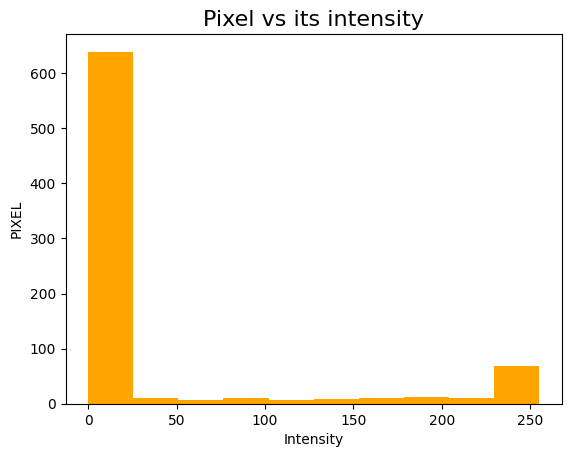

In [ ]:
plt.hist(train_images[0].reshape(784),facecolor='orange')
plt.title('Pixel vs its intensity',fontsize=16)
plt.ylabel('PIXEL')
plt.xlabel('Intensity')
plt.show()

##` Showing the sample image as a picture`

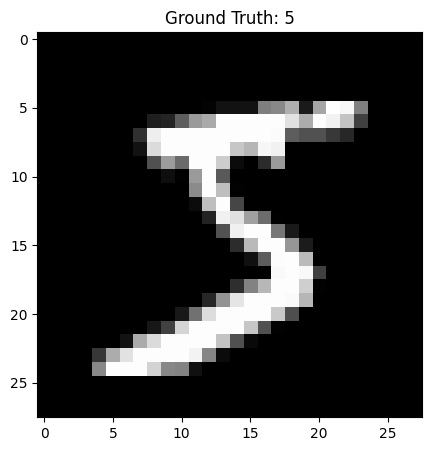

In [ ]:
plt.figure(figsize=[10, 5])
plt.imshow(train_images[0], cmap='gray')
plt.title('Ground Truth: {}'.format(train_labels[0]))
plt.show()

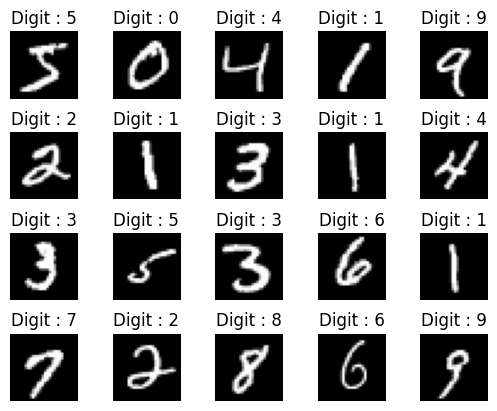

In [ ]:
for i in range(20):
  plt.subplot(4,5,i+1)
  plt.imshow(train_images[i],cmap='gray')
  plt.title("Digit : {}".format(train_labels[i]))
  plt.subplots_adjust(hspace=0.5)
  plt.axis('off')

# **Data Preprocessing**

In [ ]:
train_images, test_images = train_images / 255.0, test_images / 255.0

In [ ]:
from tensorflow.keras.utils import to_categorical
print('Original label: ', train_labels[0])
train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)
print('After conversion to categorical (one-hot): ', train_labels[0])

Original label:  5
After conversion to categorical (one-hot):  [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


# **Create the Network**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
model = Sequential()
model.add(Flatten(input_shape=(28, 28)))
model.add(Dense(512, activation='relu'))
model.add(Dense(256, activation='relu'))
model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation='softmax'))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 567,434 (2.16 MB)

 Trainable params: 567,434 (2.16 MB)

 Non-trainable params: 0 (0.00 B)

#**Configure the Network**

In [ ]:
model.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

#adam, adadelta, SGD

# **Train the Network**

In [ ]:
history = model.fit(train_images, train_labels, batch_size=256, epochs=10, verbose=1, validation_split=0.33)
model.save("mlp_model.keras")

Epoch 1/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.8808 - loss: 0.3931 - val_accuracy: 0.9210 - val_loss: 0.2554
Epoch 2/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9571 - loss: 0.1359 - val_accuracy: 0.9616 - val_loss: 0.1326
Epoch 3/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9740 - loss: 0.0849 - val_accuracy: 0.9694 - val_loss: 0.0963
Epoch 4/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9814 - loss: 0.0578 - val_accuracy: 0.9724 - val_loss: 0.0941
Epoch 5/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9876 - loss: 0.0404 - val_accuracy: 0.9708 - val_loss: 0.0995
Epoch 6/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9905 - loss: 0.0297 - val_accuracy: 0.9498 - val_loss: 0.2104
Epoch 7/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9922 - loss: 0.0233 - val_accuracy: 0.9715 - val_loss: 0.1115
Epoch 8/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9942 - loss: 0.0182 - val_accu

# **Plot the Loss and Accuracy Curves**

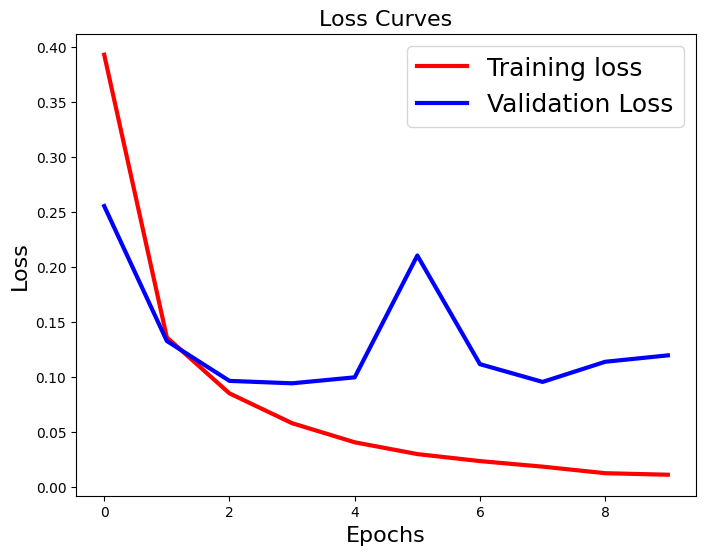

In [ ]:
plt.figure(figsize=[8, 6])
plt.plot(history.history['loss'], 'r', linewidth=3.0)
plt.plot(history.history['val_loss'], 'b', linewidth=3.0)
plt.legend(['Training loss', 'Validation Loss'], fontsize=18,loc='upper right')
plt.xlabel('Epochs', fontsize=16)
plt.ylabel('Loss', fontsize=16)
plt.title('Loss Curves', fontsize=16)
plt.show()

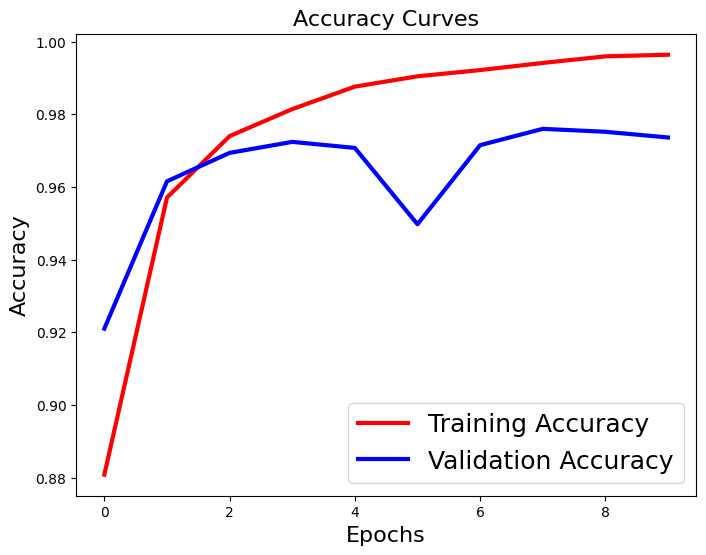

In [ ]:
plt.figure(figsize=[8, 6])
plt.plot(history.history['accuracy'], 'r', linewidth=3.0)
plt.plot(history.history['val_accuracy'], 'b', linewidth=3.0)
plt.legend(['Training Accuracy', 'Validation Accuracy'], fontsize=18,loc='lower right')
plt.xlabel('Epochs', fontsize=16)
plt.ylabel('Accuracy', fontsize=16)
plt.title('Accuracy Curves', fontsize=16)
plt.show()

# **Evaluate the Trained Network on Test Data**

In [ ]:
test_loss, test_accuracy = model.evaluate(test_images, test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9780 - loss: 0.0956


In [ ]:
print('Test Loss:', test_loss)
print('Test Accuracy: ', test_accuracy)

Test Loss: 0.09558355063199997
Test Accuracy:  0.9779999852180481


# **Prediction**

In [ ]:
prediction = model.predict(test_images[127:128])
predicted_class = np.argmax(prediction[0])
print('Prediction: {}'.format(predicted_class))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Prediction: 5


In [ ]:
prediction[0]

array([2.5133163e-17, 2.0115651e-16, 1.1821399e-18, 9.1225048e-12,
       3.2751326e-17, 1.0000000e+00, 7.0720221e-11, 2.9784497e-17,
       9.5463325e-11, 2.0656459e-11], dtype=float32)

# **Ground Truth**

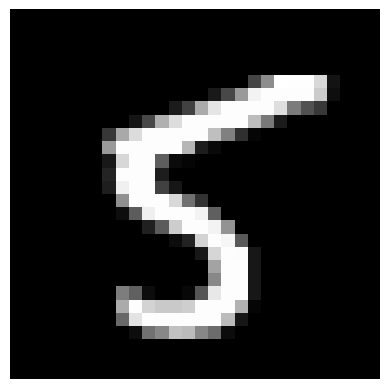

In [ ]:
plt.imshow(test_images[127], cmap='gray')
plt.axis('off')
plt.show()

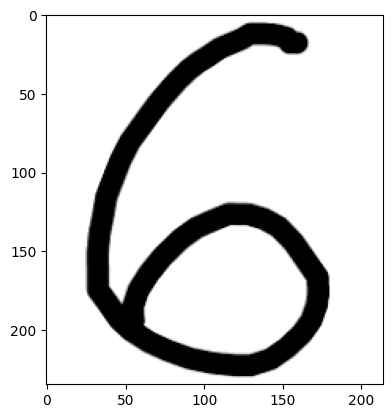

In [ ]:
import cv2
image_bgr = cv2.imread('/content/six.png', cv2.IMREAD_COLOR)
#image_bgr = cv2.imread('/content/drive/My Drive/Colab Notebooks/digit.jpg', cv2.IMREAD_COLOR)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
plt.imshow(image_rgb)
plt.axis('on')
plt.show()

# **Convert to Grayscale and Resize**

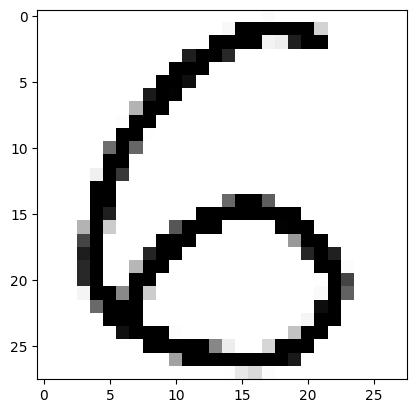

In [ ]:
image = cv2.imread('/content/six.png', cv2.IMREAD_GRAYSCALE)
image_resized = cv2.resize(image, (28, 28))
plt.imshow(image_resized, cmap='gray')
plt.axis('on')
plt.show()
image_resized = image_resized / 255.0

# **Prediction**

In [ ]:
test = np.expand_dims(image_resized, axis=0)
prediction = model.predict(test)
predicted_class = np.argmax(prediction[0])
print('Prediction : {}'.format(predicted_class))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Prediction : 5


**Loading a Model**

In [ ]:
from tensorflow.keras.models import load_model

# Loads the structure and weights all at once
loaded_model = load_model('/content/mlp_model.keras')
print('Loaded model from disk')

Loaded model from disk


**Evaluate Loaded Model on Test Data**

In [ ]:
loaded_model.compile(loss='categorical_crossentropy', optimizer='rmsprop', metrics=['accuracy'])
test_loss, test_accuracy = loaded_model.evaluate(test_images, test_labels)
print('Test Loss:', test_loss)
print('Test Accuracy:', test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9780 - loss: 0.0956
Test Loss: 0.09558355063199997
Test Accuracy: 0.9779999852180481


# Visualization of Power of the Model

##` A glance of model performance on test images`

In [ ]:
LabelNames= [ "zero","one","two","three","four","five","six","seven","eight","nine" ]

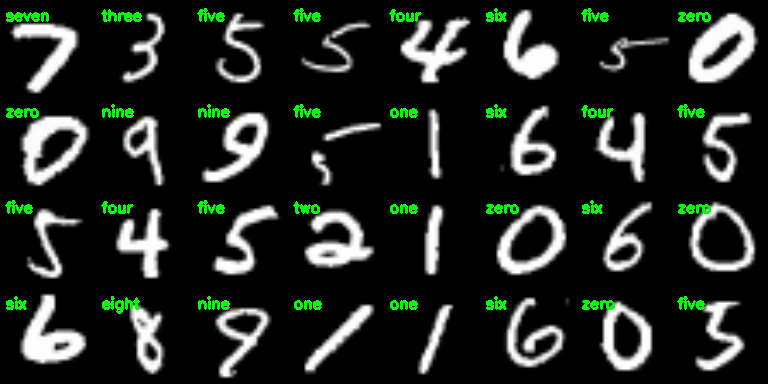

In [ ]:
import cv2
import numpy as np
from tensorflow.keras import backend as K
from imutils import build_montages
from google.colab.patches import cv2_imshow as imshow

# Initialize our list of output images
images = []

# Randomly select a few testing fashion items
for i in np.random.choice(np.arange(0, len(test_labels)), size=(32,)):
    # FIX: Add batch dimension correctly for model prediction
    probs = model.predict(test_images[i][np.newaxis, ...], verbose=0)
    prediction = probs.argmax(axis=1)
    label = LabelNames[prediction[0]]

    # FIX: Corrected indentation for the format check
    if K.image_data_format() == "channels_first":
        image = (test_images[i][0] * 255).astype("uint8")
    else:
        image = (test_images[i] * 255).astype("uint8")

    # Initialize the text label color as green (correct)
    color = (0, 255, 0)

    # FIX: Corrected indentation for the error checking
    # Checks if prediction matches the actual target index
    if prediction[0] != np.argmax(test_labels[i]):
        color = (0, 0, 255)

    # Merge the channels into one image and resize it
    image = cv2.merge([image] * 3)
    image = cv2.resize(image, (96, 96), interpolation=cv2.INTER_LINEAR)
    cv2.putText(image, label, (5, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

    # Add the image to our list of output images
    images.append(image)

# Construct the montage for the images
montage = build_montages(images, (96, 96), (8, 4))[0]

# Show the output montage
imshow(montage)

# Note: cv2.waitKey and destroyAllWindows are not needed/functional
# inside Google Colab notebook environments, so they are omitted.

##`Selecting a file from the machine/ cloud`

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving six.png to six (1).png


##`Displaying the loaded image`

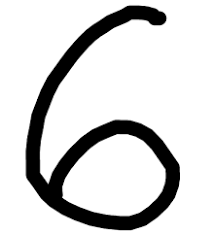

In [ ]:
from IPython.display import Image
Image('/content/six (1).png',width=250,height=250)

##` Classify the uploaded image using trained model`

In [ ]:
from tensorflow.keras.preprocessing.image import load_img
from keras.preprocessing.image import img_to_array

In [ ]:
def load_image(filename):
	# load the image
	img = load_img(filename, color_mode="grayscale", target_size=(28, 28))
	# convert to array
	img = img_to_array(img)
	# reshape into a single sample with 1 channel
	img = img.reshape(1, 28, 28)
	# prepare pixel data
	img = img.astype('float32')
	img = img / 255.0
	return img

In [ ]:
img = load_image('six (1).png')
prediction=model.predict(img)
predicted_class = np.argmax(prediction[0])
print('Predicted value : ',predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Predicted value :  5


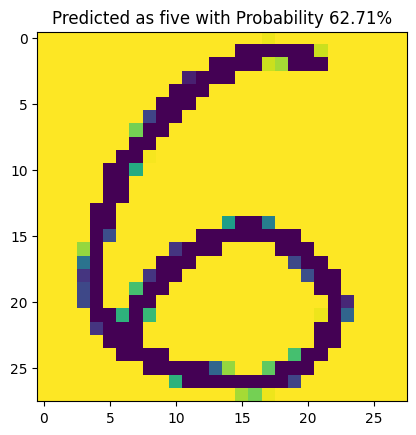

In [ ]:
plt.imshow(img.reshape(28,28))
plt.title("Predicted as {} with Probability {:.2f}%".format(LabelNames[predicted_class],np.max(prediction[0])*100))
plt.show()